## Phase 7 : Interprétabilité (Optionnel)
### 1. Feature maps

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2

In [2]:
model = keras.applications.MobileNetV2(weights= "imagenet")

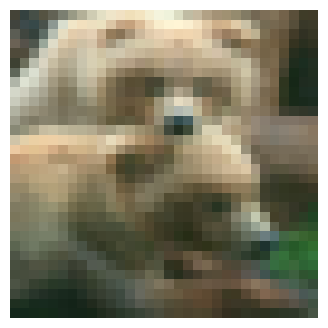

In [5]:
(X_train, y_train), _ = keras.datasets.cifar100.load_data()

idx = np.where(y_train == 3)[0]
img_original = X_train[idx[5]]

plt.figure(figsize=(4, 4))
plt.imshow(img_original)
plt.axis("off")
plt.show()

In [21]:
img_resize = 224
img_resized = cv2.resize(img_original, (img_resize, img_resize))
img_array = np.expand_dims(img_resized, 0)
print(img_array.shape)

(1, 224, 224, 3)


In [22]:
img_processed = keras.applications.mobilenet_v2.preprocess_input(img_array)

In [24]:
layer_name = "Conv1"
layer_output = model.get_layer(layer_name).output

features_model = keras.Model(inputs = model.input, outputs = layer_output)

features_maps = features_model.predict(img_processed)

print(features_maps.shape[-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
32


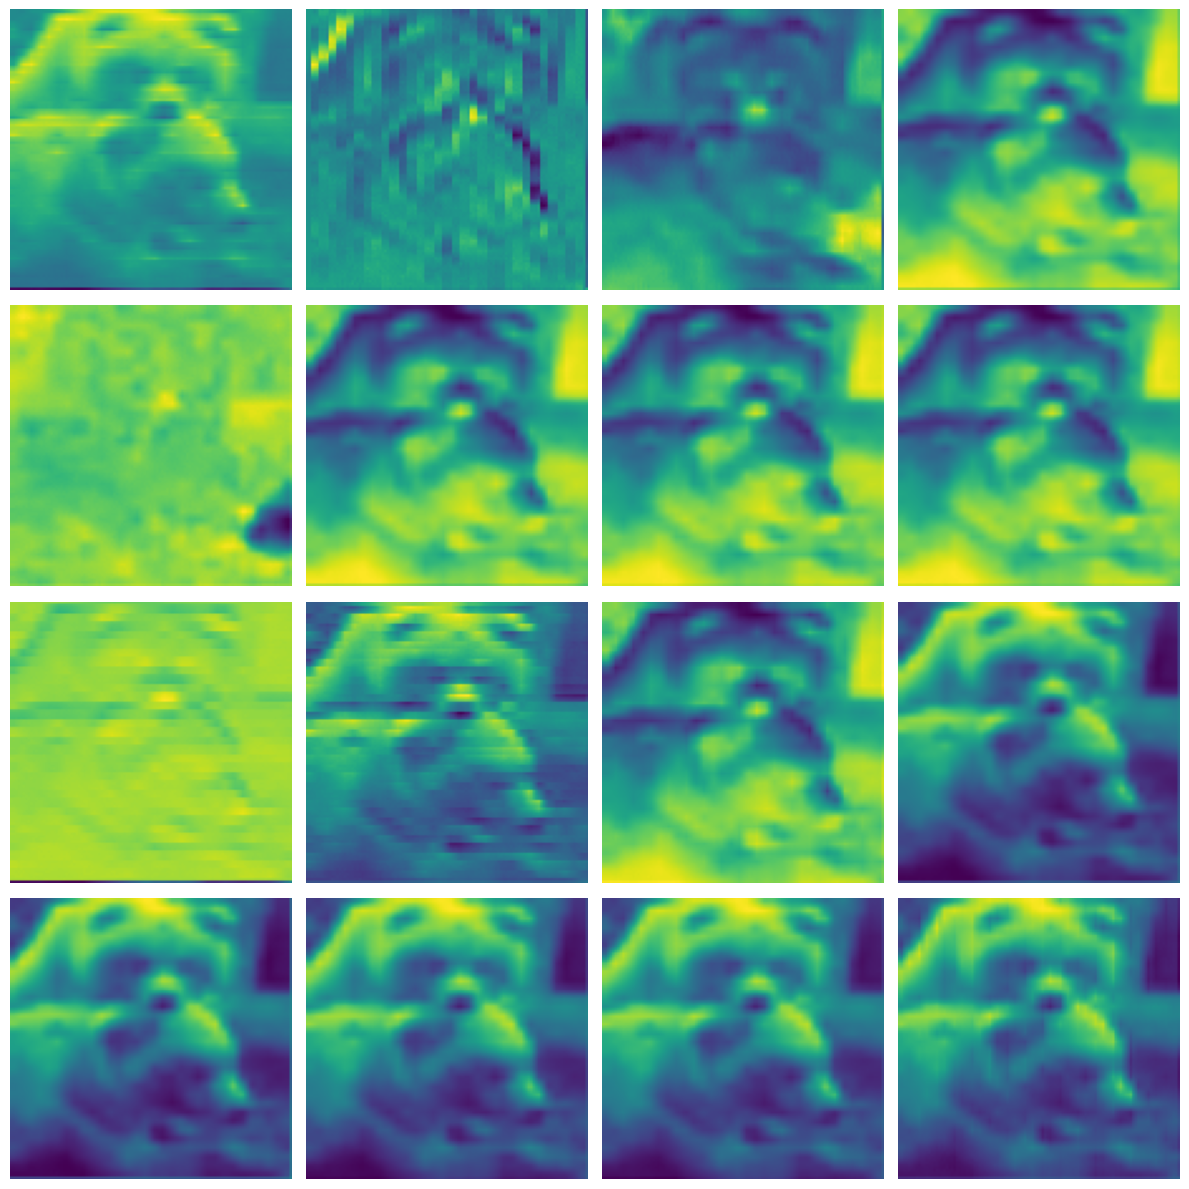

In [23]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat) :
    if i < features_maps.shape[-1] :
        ax.imshow(features_maps[0, :,:, i]) 
    ax.axis("off")


plt.tight_layout()
plt.show()

### 2. Grad-CAM

In [10]:
preds = model.predict(img_processed)
top_pred_index = np.argmax(preds[0])
top_pred_score = preds[0][top_pred_index]

decoded = keras.applications.mobilenet_v2.decode_predictions(preds, top = 1)[0][0]

print(decoded[1])
print(top_pred_score*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
Yorkshire_terrier
11.047031


In [11]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

last_output = "out_relu"
heatmap = make_gradcam_heatmap(img_processed, model, last_output)

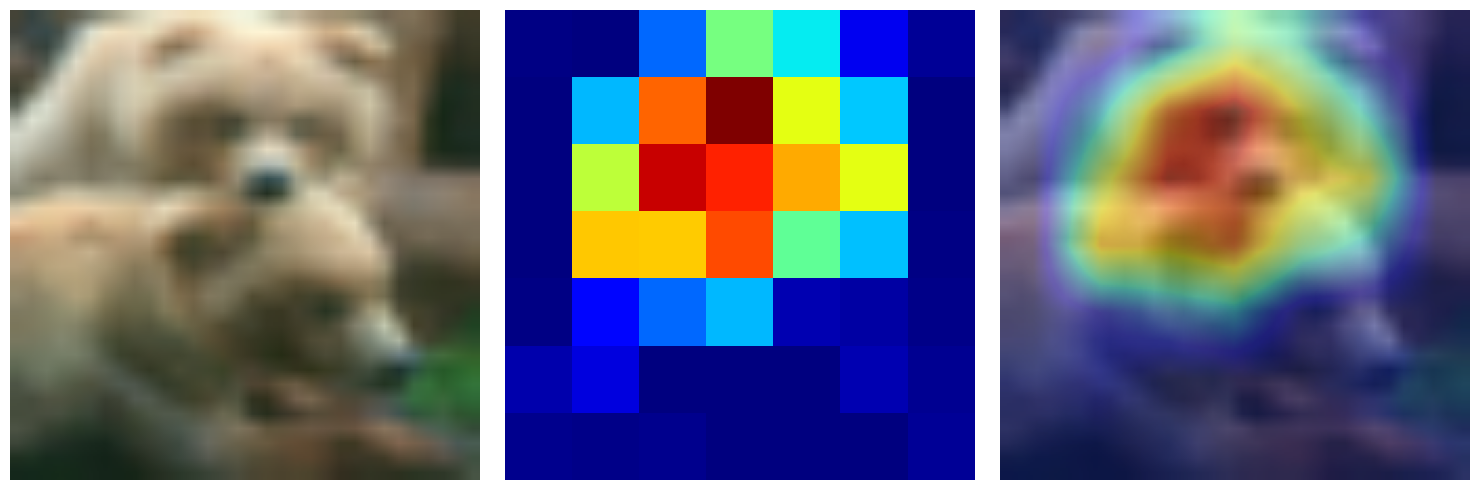

In [12]:
def superimpose_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype(np.uint8)
    
    superimposed = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    return superimposed

superimpose_img = superimpose_heatmap(img_resized, heatmap)

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(img_resized)
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].axis("off")

axes[2].imshow(superimpose_img)
axes[2].axis("off")

plt.tight_layout()
plt.show()